<a href="https://colab.research.google.com/github/offjisung-alt/MachineLearning/blob/main/9_%EC%88%9C%ED%99%98%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 순환 신경망 (RNN, Recurrent Neural Network)

## 1. 순환 신경망이란?

순환 신경망(RNN, Recurrent Neural Network)은 순서(Sequence)를 가지는 데이터를 처리하기 위해 설계된 신경망이다.

기존의 완전 연결 신경망(Dense Neural Network)은 입력 데이터가 서로 독립적이라고 가정한다.

예를 들어 다음 두 문장을 생각해 보자.

text 나는 영화를 좋아한다. 영화를 나는 좋아한다.

사용된 단어는 같지만 단어의 순서가 달라지면 의미도 달라진다.

일반 신경망은 이러한 순서 정보를 효과적으로 반영하기 어렵다.

반면 RNN은 이전 시점의 정보를 기억하면서 현재 입력을 처리하므로 순차 데이터의 패턴을 학습할 수 있다.

---

## 2. 순차 데이터(Sequential Data)

순차 데이터란 데이터의 순서가 중요한 데이터를 의미한다.

### 자연어 처리

text 나는 → 영화를 → 좋아한다

### 음성 데이터

text 음성1 → 음성2 → 음성3 → ...

### 시계열 데이터

text 월요일 → 화요일 → 수요일 → ...

### 주가 데이터

text 1000원 → 1050원 → 1030원 → ...

이처럼 현재 데이터가 이전 데이터와 관계를 가지는 경우 RNN을 사용할 수 있다.

---

## 3. RNN이 필요한 이유

기존 신경망은 현재 입력만 이용한다.

text 입력 → 출력

반면 RNN은 과거 정보를 기억한다.

text 이전 정보 + 현재 입력 → 현재 출력

즉,

> "현재를 이해하기 위해 과거를 함께 고려한다."

라는 특징을 가진다.

---

## 4. RNN의 기본 구조

RNN은 은닉층의 출력이 다음 시점의 입력으로 다시 전달되는 구조를 가진다.

text x₁ → h₁       ↓ x₂ → h₂       ↓ x₃ → h₃       ↓ x₄ → h₄

여기서

- x : 입력(Input)
- h : 은닉 상태(Hidden State)

를 의미한다.

---

## 5. 은닉 상태(Hidden State)

은닉 상태는 지금까지 입력된 정보들을 요약하여 저장하는 공간이다.

예를 들어

text 나는 → 영화를 → 좋아한다

를 처리한다면

### 첫 번째 시점

text 입력 : 나는 기억 : 나는

### 두 번째 시점

text 입력 : 영화를 기억 : 나는 + 영화를

### 세 번째 시점

text 입력 : 좋아한다 기억 : 나는 + 영화를 + 좋아한다

즉 은닉 상태는 과거 정보를 축적하는 역할을 수행한다.

---

## 6. RNN 수식

RNN의 가장 중요한 수식은 다음과 같다.

$$
h_t = \tanh(W_xx_t + W_hh_{t-1} + b)
$$

### 기호 설명

- $x_t$ : 현재 시점의 입력 데이터
- $h_{t-1}$ : 이전 시점의 은닉 상태
- $h_t$ : 현재 시점의 은닉 상태
- $W_x$ : 입력에 대한 가중치
- $W_h$ : 이전 은닉 상태에 대한 가중치
- $b$ : 편향(Bias)
- $\tanh$ : 활성화 함수

---

## 7. 수식의 의미

현재 상태는

$$
현재 입력 + 이전 기억
$$

을 이용하여 계산된다.

즉,

$$
h_t = f(x_t, h_{t-1})
$$

이다.

현재 단어만 보는 것이 아니라 이전까지의 문맥도 함께 고려한다.

---

## 8. 시간 펼침(Time Unrolling)

RNN은 내부적으로 순환 구조를 가지지만 실제 계산 시에는 시간축으로 펼쳐서 생각한다.

예를 들어

text 나는 영화를 좋아한다

라는 문장은

text x₁ → h₁ → y₁ x₂ → h₂ → y₂ x₃ → h₃ → y₃

처럼 펼쳐진 구조로 계산된다.

이를 Time Unrolling이라 한다.

---

## 9. 가중치 공유(Weight Sharing)

RNN의 중요한 특징은 모든 시점에서 같은 가중치를 사용한다는 것이다.

즉

$$
W_x, W_h
$$

는 모든 시점에서 동일하다.

### 장점

- 파라미터 수 감소
- 메모리 절약
- 학습 효율 증가

---

## 10. 출력 구조

### One-to-One

text 입력 1개 → 출력 1개

일반 신경망

---

### One-to-Many

text 입력 1개 → 출력 여러 개

예)

이미지 캡션 생성

text 사진 → "고양이가 의자에 앉아 있다"

---

### Many-to-One

text 입력 여러 개 → 출력 1개

예)

감성 분석

text 문장 → 긍정

---

### Many-to-Many

text 입력 여러 개 → 출력 여러 개

예)

기계 번역

text 안녕하세요 ↓ Hello

---

## 11. RNN의 학습

RNN도 일반 신경망처럼 손실 함수를 최소화하도록 학습한다.

학습 과정은 다음과 같다.

### 순전파

입력 데이터를 이용해 출력 계산

↓

### 손실 계산

예측값과 정답 비교

↓

### 역전파

오차를 뒤로 전달

↓

### 가중치 갱신

경사하강법(SGD, Adam 등)

---

## 12. BPTT (Back Propagation Through Time)

RNN은 시간축으로 연결되어 있기 때문에 일반 역전파 대신

BPTT(시간 역전파 알고리즘)

를 사용한다.

시간 방향으로 펼쳐진 모든 RNN 층에 대해 오차를 전파하여 가중치를 업데이트한다.

---

## 13. 기울기 소실(Vanishing Gradient)

RNN의 대표적인 문제점이다.

역전파 과정에서 작은 값이 반복적으로 곱해지면

$$
0.1 \times 0.1 \times 0.1 \times \cdots
$$

와 같이 0에 가까워진다.

결과적으로 오래된 정보는 학습되지 않는다.

---

## 14. 기울기 폭주(Exploding Gradient)

반대로 큰 값이 계속 곱해지면

$$
10 \times 10 \times 10 \times \cdots
$$

처럼 값이 지나치게 커질 수 있다.

이 경우 학습이 매우 불안정해진다.

---

## 15. 장기 의존성(Long-Term Dependency)

문장이 길어질수록 오래전 정보를 기억하기 어려워진다.

예를 들어

text 나는 어제 친구와 함께 영화를 보러 갔는데 ... ... 결말이 정말 좋았다.

와 같은 긴 문장에서 처음 등장한 정보가 뒤쪽에 영향을 주어야 하지만 기본 RNN은 이를 잘 기억하지 못한다.

---

## 16. LSTM

LSTM(Long Short-Term Memory)은 RNN의 장기 의존성 문제를 해결하기 위해 개발되었다.

### 특징

- 셀 상태(Cell State) 사용
- 중요한 정보만 기억
- 불필요한 정보 제거
- 장기 기억 가능

LSTM은 입력 게이트, 삭제 게이트, 출력 게이트를 사용하여 정보를 제어한다.

---

## 17. GRU

GRU(Gated Recurrent Unit)는 LSTM을 단순화한 구조이다.

### 특징

- 구조가 단순함
- 파라미터 수 감소
- 학습 속도 향상
- LSTM과 비슷한 성능

---

## 18. RNN의 장점

### 순서 정보를 학습 가능

문장, 음성, 시계열 데이터를 처리할 수 있다.

### 가변 길이 입력 가능

입력 길이가 달라도 처리 가능하다.

### 파라미터 공유

모든 시점에서 같은 가중치를 사용한다.

---

## 19. RNN의 단점

### 병렬 처리 어려움

순서대로 계산해야 한다.

### 학습 속도가 느림

이전 시점 계산이 끝나야 다음 시점 계산 가능하다.

### 기울기 소실 문제

긴 문장을 처리하기 어렵다.

### 장기 의존성 문제

오래된 정보를 기억하기 어렵다.

---

## 20. 정리

RNN은 순차 데이터를 처리하기 위해 만들어진 신경망이다.

핵심 아이디어는

$$
현재 입력 + 이전 기억 = 현재 상태
$$

이다.

은닉 상태(Hidden State)를 이용하여 과거 정보를 저장하며, 자연어 처리·음성 인식·시계열 예측 등에 사용된다.

하지만 기울기 소실과 장기 의존성 문제가 존재하며, 이를 개선한 모델이 LSTM과 GRU이다.

## 모델 파라미터 수 (Number of Parameters)

순환 신경망(RNN)의 모델 파라미터는 크게 세 가지로 구성된다.

1. 입력층 → 순환층 가중치
2. 이전 은닉 상태 → 현재 은닉 상태 가중치
3. 편향(Bias)

예를 들어 입력 노드가 4개이고 순환층의 노드가 3개라고 가정하자.

---

### 1. 입력층 → 순환층 가중치

현재 입력 데이터는 4개의 특성을 가진다.

순환층에는 3개의 뉴런이 존재하므로 입력과 순환층을 연결하는 가중치 행렬의 크기는

$$
(4, 3)
$$

이다.

따라서 필요한 파라미터 수는

$$
4 \times 3 = 12
$$

개이다.

---

### 2. 이전 은닉 상태 → 현재 은닉 상태 가중치

RNN은 현재 입력뿐만 아니라 이전 시점의 은닉 상태도 함께 사용한다.

은닉 상태의 크기가 3이므로 이전 은닉 상태와 현재 은닉 상태를 연결하는 가중치 행렬의 크기는

$$
(3, 3)
$$

이다.

따라서 필요한 파라미터 수는

$$
3 \times 3 = 9
$$

개이다.

---

### 3. 편향(Bias)

순환층의 각 뉴런은 하나의 편향 값을 가진다.

순환층의 노드 수가 3개이므로

$$
3
$$

개의 편향이 존재한다.

---

### 4. 전체 모델 파라미터 수

전체 파라미터 수는 다음과 같다.

$$
12 + 9 + 3
$$

$$
= 24
$$

따라서 입력 노드가 4개이고 순환층 노드가 3개인 RNN의 모델 파라미터 수는

$$
24
$$

개이다.

---

### 일반식

입력 노드 수를 $n$,

순환층 노드 수를 $m$이라고 하면

#### 입력 가중치

$$
n \times m
$$

#### 순환 가중치

$$
m \times m
$$

#### 편향

$$
m
$$

따라서 전체 모델 파라미터 수는

$$
nm + m^2 + m
$$

으로 계산할 수 있다.

---

### Dense 층과의 차이

일반적인 Dense 층의 파라미터 수는

$$
nm + m
$$

이다.

반면 RNN은 이전 은닉 상태를 연결하는 순환 가중치

$$
m^2
$$

가 추가된다.

따라서 같은 노드 수를 사용하더라도 RNN의 파라미터 수가 더 많아진다.

# 타임 스텝(Time Step)

## 1. 타임 스텝이란?

타임 스텝(Time Step)은 순환 신경망(RNN)이 순서 데이터를 처리할 때 데이터를 나누는 단위를 의미한다.

즉,

> 순환 신경망이 몇 번의 순서에 걸쳐 데이터를 입력받는가를 나타내는 값이다.

RNN은 데이터를 한 번에 입력받는 것이 아니라 순서대로 하나씩 입력받는다.

---

## 2. 문장 데이터 예시

다음 문장을 생각해보자.

text I am a boy

RNN은 문장을 한 번에 처리하지 않고 단어를 순서대로 입력받는다.

text 1번째 시점 : I 2번째 시점 : am 3번째 시점 : a 4번째 시점 : boy

따라서 타임 스텝의 개수는

$$
4
$$

가 된다.

---

## 3. 시계열 데이터 예시

최근 5일간의 주가 데이터를 입력한다고 가정하자.

text 1000 1050 1030 1100 1200

RNN은 데이터를 다음과 같이 처리한다.

text 1일차 2일차 3일차 4일차 5일차

따라서

$$
\text{time steps} = 5
$$

가 된다.

---

## 4. RNN 입력 데이터의 형태

RNN의 입력 데이터는 일반적으로 다음과 같은 형태를 가진다.

$$
(batch_size,\ time_steps,\ features)
$$

### 구성 요소

- batch_size : 한 번에 입력되는 샘플 수
- time_steps : 순서 데이터의 길이
- features : 각 시점에서의 특성 수

---

## 5. 입력 형태 예시

입력 데이터의 형태가

python (1, 4, 3)

이라면

- batch_size = 1
- time_steps = 4
- features = 3

을 의미한다.

즉,

text 샘플 1개  단어 4개  각 단어를 3개의 숫자로 표현

한 것이다.

---

## 6. 타임 스텝과 뉴런 수의 차이

많은 사람들이 타임 스텝과 뉴런 수를 혼동한다.

### 타임 스텝

text 몇 번 입력할 것인가?

를 의미한다.

예)

text I → am → a → boy

이면

$$
time_steps = 4
$$

이다.

### 뉴런 수

text 각 시점에서 얼마나 많은 정보를 저장할 것인가?

를 의미한다.

예)

python SimpleRNN(5)

이면

은닉 상태의 크기가

$$
5
$$

이다.

---

## 7. 정리

타임 스텝은 순서 데이터의 길이를 의미한다.

예를 들어

text I am a boy

는 단어가 4개이므로

$$
time_steps = 4
$$

이다.

따라서 입력 형태

python (1, 4, 3)

에서 4는 타임 스텝을 의미한다.

# RNN의 출력 형태와 모델 파라미터 수

## 1. 입력 데이터 예시

다음과 같은 입력 데이터가 있다고 가정하자.

python (1, 4, 3)

이는

$$
(batch_size,\ time_steps,\ features)
$$

형태를 의미한다.

즉,

- batch_size = 1
- time_steps = 4
- features = 3

이다.

---

## 2. 순환층의 뉴런 수

다음과 같이 순환층을 구성했다고 가정하자.

python SimpleRNN(5)

여기서 5는 순환층의 뉴런 수(은닉 상태 크기)를 의미한다.

즉,

$$
hidden_size = 5
$$

이다.

---

## 3. 입력이 순환층을 통과하는 과정

입력 데이터

text I am a boy

는 순서대로 RNN에 전달된다.

text t=1 : I t=2 : am t=3 : a t=4 : boy

각 시점마다 3개의 특성을 입력받고 5개의 은닉 상태를 생성한다.

text h₁ : (5,) h₂ : (5,) h₃ : (5,) h₄ : (5,)

---

## 4. 왜 출력이 (1, 5)가 되는가?

기본적으로 Keras의 RNN은

python return_sequences=False

가 기본값이다.

즉 마지막 시점의 은닉 상태만 출력한다.

text h₁ 버림 h₂ 버림 h₃ 버림 h₄ 출력

따라서 출력 형태는

python (1, 5)

가 된다.

---

## 5. return_sequences=True인 경우

python SimpleRNN(5, return_sequences=True)

로 설정하면 모든 시점의 은닉 상태를 반환한다.

따라서 출력 형태는

python (1, 4, 5)

가 된다.

즉

text h₁ h₂ h₃ h₄

를 모두 출력한다.

---

## 6. 모델 파라미터 수 계산

입력 특성 수가 3개이고 순환층의 뉴런 수가 5개인 경우를 생각해보자.

### 입력 가중치

입력과 은닉층을 연결하는 가중치의 크기는

$$
(3, 5)
$$

이다.

따라서

$$
3 \times 5 = 15
$$

개의 파라미터가 존재한다.

---

### 순환 가중치

이전 은닉 상태와 현재 은닉 상태를 연결하는 가중치의 크기는

$$
(5, 5)
$$

이다.

따라서

$$
5 \times 5 = 25
$$

개의 파라미터가 존재한다.

---

### 편향(Bias)

은닉층의 뉴런 수가 5개이므로

$$
5
$$

개의 편향이 존재한다.

---

### 전체 파라미터 수

전체 파라미터 수는

$$
15 + 25 + 5
$$

$$
= 45
$$

개이다.

---

## 7. 일반식

입력 특성 수를 $n$,

순환층 뉴런 수를 $m$이라고 하면

전체 파라미터 수는

$$
nm + m^2 + m
$$

으로 계산할 수 있다.

---

## 8. 정리

- 타임 스텝은 순서 데이터의 길이이다.
- 뉴런 수는 은닉 상태의 크기이다.
- 입력 형태 (1,4,3)에서 4는 타임 스텝, 3은 특성 수를 의미한다.
- SimpleRNN(5)의 출력 형태는 (1,5)이다.
- return_sequences=True이면 출력 형태는 (1,4,5)이다.
- RNN의 파라미터 수는

$$
nm + m^2 + m
$$

으로 계산한다.

In [1]:
from tensorflow.keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=300)
print(train_input.shape, test_input.shape)
print(len(train_input[0]))
print(len(train_input[1]))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(25000,) (25000,)
218
189


In [2]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 284, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [3]:
# 리뷰가 긍정인지 부정인지 판단.
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [4]:
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [5]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

In [6]:
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


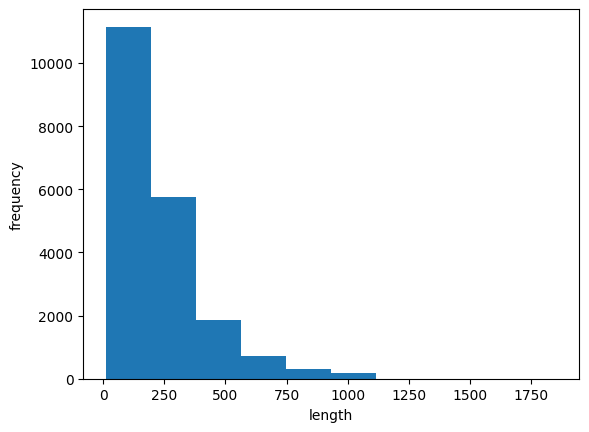

In [7]:
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [8]:
# train_input의 길이를 100으로 맞춘다.
# maxlen에 값을 입력하면 그 값에 맞춰 padding한다. 길이를 초과할 경우 앞 부분을 잘라낸다.

from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)

In [9]:
print(train_seq.shape)

(20000, 100)


In [10]:
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [11]:
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


In [12]:
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94 205   2  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


In [13]:
val_seq = pad_sequences(val_input, maxlen=100)

In [14]:
from tensorflow import keras
model = keras.Sequential()

# 300이 나온 이유 : 20 50 100 으로 토큰화된 것을 그대로 사용하면 큰 값에 큰 가중치를 사용하게 된다
# 그래서 원-핫 인코딩을 하기 때문에 300이 나옴(단어의 최대 갯수)
model.add(keras.layers.SimpleRNN(8, input_shape=(100, 300)))
model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
# to_categorical() : 정수 배열을 입력하면 자동으로 원-핫 인코딩된 배열을 반환해준다.
train_oh = keras.utils.to_categorical(train_seq)

In [16]:
print(train_oh.shape)

(20000, 100, 300)


In [17]:
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [18]:
print(np.sum(train_oh[0][0]))

1.0


In [19]:
val_oh = keras.utils.to_categorical(val_seq)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         2,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,481 (9.69 KB)

 Trainable params: 2,481 (9.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_pb = keras.callbacks.ModelCheckpoint('best-simplearn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target), callbacks=[checkpoint_pb, early_stopping_cb])

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [ ]:
print(train_seq.nbytes, train_oh.nbytes)

In [ ]:
model2 = keras.Sequential()
model2.add(keras.layers.Embedding(300, 16, input_length=100))
model2.add(keras.layers.SimpleRNN(8))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
model2.summary()

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplearn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model2.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()